# 06 - Experimentacion con K=5, K=6 y K=7 (K-Modes - RITA)

En el notebook 03 se determino que K=4 era el valor optimo segun el metodo del codo. En este notebook exploramos que sucede al aumentar K a **5, 6 y 7** para descubrir si aparecen subgrupos clinicamente relevantes que el modelo con K=4 no captura.

**Objetivo:** Comparar los perfiles de clusteres obtenidos con K=5, K=6 y K=7, analizar los costos y la distribucion de pacientes en cada agrupamiento.

## 1. Carga de datos y preparacion

Replicamos exactamente la misma preparacion del notebook 03: seleccion de variables, discretizacion de edad y codificacion.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset procesado
df = pd.read_csv('../data/processed/rita_limpio.csv')
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 82106 filas x 13 columnas


,IDPTE,PTESXN,FECHA_DIAGNÓSTICO,EDAD_DIAGNÓSTICO,TOPOGRAFÍA,TOPOGRAFÍA_N,MORFOLOGÍA,MORFOLOGÍA_N,COMPORTAMIENTO,COMPORTAMIENTO_N,METODO_DIAGNÓSTICO,METODO_DIAGNÓSTICO_N,SEXO_NUM
0,1402,Hombre,2012-04-30,69,C17.0,(C17.0)-Duodeno,8140.0,"(8140)-Adenocarcinoma, SAI",3,"Maligno, Sitio primario",8,Histología de tumor primario,0
1,28769,Hombre,2014-12-16,81,C16.9,"(C16.9)-Gástrico, SAI",8144.0,"(8144)-Adenocarcinoma, tipo intestinal (C16._)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...,0
2,52073,Mujer,2016-05-15,66,C50.9,"(C50.9)-Mama, SAI",8500.0,"(8500)-Carcinoma ductal infiltrante, SAI (C50._)",3,"Maligno, Sitio primario",8,Histología de tumor primario,1
3,28576,Mujer,2014-09-03,59,C54.1,(C54.1)-Endometrio,8930.0,"(8930)-Sarcoma endometrial, SAI (C54.1)",3,"Maligno, Sitio primario",3,Diagnóstico por imágenes y/o endoscopía sin to...,1
4,61923,Mujer,2016-04-25,61,C56.9,(C56.9)-Ovario,8460.0,(8460)-Cistadenocarcinoma seroso papilar (C56.9),3,"Maligno, Sitio primario",8,Histología de tumor primario,1


In [3]:
# Seleccion de columnas relevantes (mismas que en notebook 03)
selected_cols = ['PTESXN', 'TOPOGRAF\u00cdA_N', 'MORFOLOG\u00cdA_N', 'EDAD_DIAGN\u00d3STICO']
df_subset = df[selected_cols].copy()

# Discretizacion de la Edad en 4 rangos
bins = [0, 18, 45, 65, 120]
labels_edad = ['Infantil-Juvenil', 'Adulto Joven', 'Adulto', 'Adulto Mayor']
df_subset['EDAD_RANGO'] = pd.cut(df_subset['EDAD_DIAGN\u00d3STICO'], bins=bins, labels=labels_edad)
df_subset = df_subset.drop(columns=['EDAD_DIAGN\u00d3STICO'])

# Codificacion con LabelEncoder para K-Modes
le = LabelEncoder()
df_encoded = df_subset.astype(str).apply(le.fit_transform)

print(f'Variables para clustering: {list(df_subset.columns)}')
print(f'Filas: {len(df_encoded)}')
df_encoded.head()

Variables para clustering: ['PTESXN', 'TOPOGRAFÍA_N', 'MORFOLOGÍA_N', 'EDAD_RANGO']
Filas: 82106


,PTESXN,TOPOGRAFÍA_N,MORFOLOGÍA_N,EDAD_RANGO
0,0,146,149,2
1,0,145,156,2
2,1,567,394,2
3,1,591,600,0
4,1,599,343,0


## 2. Referencia: Modelo base con K=4

Primero entrenamos con K=4 como referencia para poder comparar directamente.

In [4]:
# K=4 como referencia (mismo que notebook 03)
km_4 = KModes(n_clusters=4, init='random', n_init=5, verbose=0, random_state=42)
clusters_4 = km_4.fit_predict(df_encoded)

df_subset_4 = df_subset.copy()
df_subset_4['Cluster'] = clusters_4

interp_4 = df_subset_4.groupby('Cluster').agg(lambda x: x.value_counts().index[0])
interp_4['Tamano'] = df_subset_4['Cluster'].value_counts().sort_index()

print(f'=== K=4 (Referencia) | Costo: {km_4.cost_} ===')
interp_4

=== K=4 (Referencia) | Costo: 150855.0 ===


,PTESXN,TOPOGRAFÍA_N,MORFOLOGÍA_N,EDAD_RANGO,Tamano
Cluster,,,,,
0,Mujer,"(C50.9)-Mama, SAI","(8140)-Adenocarcinoma, SAI",Adulto Mayor,24851
1,Hombre,"(C62.9)-Testículo, SAI","(8140)-Adenocarcinoma, SAI",Adulto,22583
2,Mujer,"(C50.9)-Mama, SAI","(8140)-Adenocarcinoma, SAI",Adulto,21752
3,Mujer,(C53.9)-Cuello uterino,(8077)-Neoplasia intraepitelial cervical. grad...,Adulto Joven,12920


---
## 3. Experimento con K=5

Aumentamos a 5 clusteres para ver si aparece un subgrupo adicional que no se detectaba con K=4.

In [5]:
km_5 = KModes(n_clusters=5, init='random', n_init=5, verbose=0, random_state=42)
clusters_5 = km_5.fit_predict(df_encoded)

df_subset_5 = df_subset.copy()
df_subset_5['Cluster'] = clusters_5

interp_5 = df_subset_5.groupby('Cluster').agg(lambda x: x.value_counts().index[0])
interp_5['Tamano'] = df_subset_5['Cluster'].value_counts().sort_index()

print(f'=== K=5 | Costo: {km_5.cost_} ===')
interp_5

=== K=5 | Costo: 141494.0 ===


,PTESXN,TOPOGRAFÍA_N,MORFOLOGÍA_N,EDAD_RANGO,Tamano
Cluster,,,,,
0,Mujer,"(C50.9)-Mama, SAI","(8140)-Adenocarcinoma, SAI",Adulto Mayor,17172
1,Hombre,"(C62.9)-Testículo, SAI","(8140)-Adenocarcinoma, SAI",Adulto,22396
2,Mujer,"(C50.9)-Mama, SAI","(8140)-Adenocarcinoma, SAI",Adulto,21752
3,Mujer,(C53.9)-Cuello uterino,(8077)-Neoplasia intraepitelial cervical. grad...,Adulto Joven,12920
4,Hombre,(C61.9)-Próstata. SAI,(8070)-Carcinoma escamoso,Adulto Mayor,7866


In [6]:
# Distribucion detallada por cluster para K=5
print('--- Distribucion de Sexo por Cluster (K=5) ---')
sexo_k5 = pd.crosstab(df_subset_5['Cluster'], df_subset_5['PTESXN'], normalize='index') * 100
display(sexo_k5.round(2))

print('\n--- Distribucion de Rango de Edad por Cluster (K=5) ---')
edad_k5 = pd.crosstab(df_subset_5['Cluster'], df_subset_5['EDAD_RANGO'], normalize='index') * 100
display(edad_k5.round(2))

print('\n--- Top 3 Topografias por Cluster (K=5) ---')
for c in sorted(df_subset_5['Cluster'].unique()):
    mask = df_subset_5['Cluster'] == c
    top3 = df_subset_5.loc[mask, 'TOPOGRAF\u00cdA_N'].value_counts().head(3)
    print(f'\nCluster {c} (n={mask.sum()}):')
    for topo, count in top3.items():
        print(f'  {topo}: {count} ({count/mask.sum()*100:.1f}%)')

--- Distribucion de Sexo por Cluster (K=5) ---


PTESXN,Hombre,Mujer
Cluster,,
0,16.0,84.0
1,100.0,0.0
2,0.0,100.0
3,0.0,100.0
4,100.0,0.0



--- Distribucion de Rango de Edad por Cluster (K=5) ---


EDAD_RANGO,Infantil-Juvenil,Adulto Joven,Adulto,Adulto Mayor
Cluster,,,,
0,1.40,19.12,0.00,79.48
1,1.52,25.31,73.08,0.08
2,0.00,0.00,100.00,0.00
3,0.12,97.00,2.69,0.19
4,0.01,2.35,0.01,97.62



--- Top 3 Topografias por Cluster (K=5) ---

Cluster 0 (n=17172):
  (C50.9)-Mama, SAI: 4781 (27.8%)
  (C20.9)-Recto, SAI: 710 (4.1%)
  (C18.9)-Colon, SAI: 676 (3.9%)

Cluster 1 (n=22396):
  (C62.9)-Testículo, SAI: 1715 (7.7%)
  (C42.1)-Médula ósea: 1361 (6.1%)
  (C64.9)-Riñón, SAI: 1244 (5.6%)

Cluster 2 (n=21752):
  (C50.9)-Mama, SAI: 5032 (23.1%)
  (C53.9)-Cuello uterino: 1865 (8.6%)
  (C50.4)-Cuadrante superior externo de la mama: 1208 (5.6%)

Cluster 3 (n=12920):
  (C53.9)-Cuello uterino: 5481 (42.4%)
  (C53.9)-Cérvix, SAI: 1502 (11.6%)
  (C50.4)-Cuadrante superior externo de la mama: 600 (4.6%)

Cluster 4 (n=7866):
  (C61.9)-Próstata. SAI: 1205 (15.3%)
  (C64.9)-Riñón, SAI: 401 (5.1%)
  (C34.9)-Pulmón, SAI: 387 (4.9%)


---
## 4. Experimento con K=6

Con K=6 buscamos aun mas granularidad en los perfiles de pacientes.

In [7]:
km_6 = KModes(n_clusters=6, init='random', n_init=5, verbose=0, random_state=42)
clusters_6 = km_6.fit_predict(df_encoded)

df_subset_6 = df_subset.copy()
df_subset_6['Cluster'] = clusters_6

interp_6 = df_subset_6.groupby('Cluster').agg(lambda x: x.value_counts().index[0])
interp_6['Tamano'] = df_subset_6['Cluster'].value_counts().sort_index()

print(f'=== K=6 | Costo: {km_6.cost_} ===')
interp_6

=== K=6 | Costo: 136195.0 ===


,PTESXN,TOPOGRAFÍA_N,MORFOLOGÍA_N,EDAD_RANGO,Tamano
Cluster,,,,,
0,Mujer,"(C50.9)-Mama, SAI","(8140)-Adenocarcinoma, SAI",Adulto Mayor,16415
1,Hombre,"(C62.9)-Testículo, SAI","(8140)-Adenocarcinoma, SAI",Adulto,22367
2,Mujer,(C53.9)-Cuello uterino,"(8140)-Adenocarcinoma, SAI",Adulto,16118
3,Mujer,(C53.9)-Cuello uterino,(8077)-Neoplasia intraepitelial cervical. grad...,Adulto Joven,12431
4,Hombre,(C61.9)-Próstata. SAI,(8070)-Carcinoma escamoso,Adulto Mayor,7866
5,Mujer,"(C50.9)-Mama, SAI","(8500)-Carcinoma ductal infiltrante, SAI (C50._)",Adulto,6909


In [8]:
# Distribucion detallada por cluster para K=6
print('--- Distribucion de Sexo por Cluster (K=6) ---')
sexo_k6 = pd.crosstab(df_subset_6['Cluster'], df_subset_6['PTESXN'], normalize='index') * 100
display(sexo_k6.round(2))

print('\n--- Distribucion de Rango de Edad por Cluster (K=6) ---')
edad_k6 = pd.crosstab(df_subset_6['Cluster'], df_subset_6['EDAD_RANGO'], normalize='index') * 100
display(edad_k6.round(2))

print('\n--- Top 3 Topografias por Cluster (K=6) ---')
for c in sorted(df_subset_6['Cluster'].unique()):
    mask = df_subset_6['Cluster'] == c
    top3 = df_subset_6.loc[mask, 'TOPOGRAF\u00cdA_N'].value_counts().head(3)
    print(f'\nCluster {c} (n={mask.sum()}):')
    for topo, count in top3.items():
        print(f'  {topo}: {count} ({count/mask.sum()*100:.1f}%)')

--- Distribucion de Sexo por Cluster (K=6) ---


PTESXN,Hombre,Mujer
Cluster,,
0,16.69,83.31
1,100.00,0.00
2,0.00,100.00
3,0.00,100.00
4,100.00,0.00
5,0.52,99.48



--- Distribucion de Rango de Edad por Cluster (K=6) ---


EDAD_RANGO,Infantil-Juvenil,Adulto Joven,Adulto,Adulto Mayor
Cluster,,,,
0,1.46,15.07,0.33,83.14
1,1.52,25.35,73.05,0.08
2,0.04,0.84,99.12,0.00
3,0.09,99.72,0.00,0.19
4,0.01,2.35,0.01,97.62
5,0.01,11.71,88.28,0.00



--- Top 3 Topografias por Cluster (K=6) ---

Cluster 0 (n=16415):
  (C50.9)-Mama, SAI: 4025 (24.5%)
  (C20.9)-Recto, SAI: 710 (4.3%)
  (C18.9)-Colon, SAI: 676 (4.1%)

Cluster 1 (n=22367):
  (C62.9)-Testículo, SAI: 1715 (7.7%)
  (C42.1)-Médula ósea: 1361 (6.1%)
  (C64.9)-Riñón, SAI: 1244 (5.6%)

Cluster 2 (n=16118):
  (C53.9)-Cuello uterino: 2355 (14.6%)
  (C53.9)-Cérvix, SAI: 1056 (6.6%)
  (C54.1)-Endometrio: 808 (5.0%)

Cluster 3 (n=12431):
  (C53.9)-Cuello uterino: 4992 (40.2%)
  (C53.9)-Cérvix, SAI: 1502 (12.1%)
  (C50.4)-Cuadrante superior externo de la mama: 600 (4.8%)

Cluster 4 (n=7866):
  (C61.9)-Próstata. SAI: 1205 (15.3%)
  (C64.9)-Riñón, SAI: 401 (5.1%)
  (C34.9)-Pulmón, SAI: 387 (4.9%)

Cluster 5 (n=6909):
  (C50.9)-Mama, SAI: 5817 (84.2%)
  (C50.4)-Cuadrante superior externo de la mama: 507 (7.3%)
  (C50.9)-Glándula mamaria: 156 (2.3%)


---
## 5. Experimento con K=7

K=7 es el maximo que exploramos aqui. Buscamos ver si hay subgrupos minoritarios pero clinicamente distintos.

In [9]:
km_7 = KModes(n_clusters=7, init='random', n_init=5, verbose=0, random_state=42)
clusters_7 = km_7.fit_predict(df_encoded)

df_subset_7 = df_subset.copy()
df_subset_7['Cluster'] = clusters_7

interp_7 = df_subset_7.groupby('Cluster').agg(lambda x: x.value_counts().index[0])
interp_7['Tamano'] = df_subset_7['Cluster'].value_counts().sort_index()

print(f'=== K=7 | Costo: {km_7.cost_} ===')
interp_7

=== K=7 | Costo: 131579.0 ===


,PTESXN,TOPOGRAFÍA_N,MORFOLOGÍA_N,EDAD_RANGO,Tamano
Cluster,,,,,
0,Mujer,"(C50.9)-Mama, SAI","(8010)-Carcinoma, SAI",Adulto Mayor,16232
1,Hombre,"(C62.9)-Testículo, SAI",(8070)-Carcinoma escamoso,Adulto,19068
2,Mujer,(C53.9)-Cuello uterino,"(8140)-Adenocarcinoma, SAI",Adulto,14857
3,Mujer,(C53.9)-Cuello uterino,(8077)-Neoplasia intraepitelial cervical. grad...,Adulto Joven,11912
4,Hombre,(C61.9)-Próstata. SAI,"(8140)-Adenocarcinoma, SAI",Adulto Mayor,9913
5,Mujer,"(C50.9)-Mama, SAI","(8500)-Carcinoma ductal infiltrante, SAI (C50._)",Adulto,5826
6,Hombre,"(C20.9)-Recto, SAI","(8140)-Adenocarcinoma, SAI",Adulto,4298


In [10]:
# Distribucion detallada por cluster para K=7
print('--- Distribucion de Sexo por Cluster (K=7) ---')
sexo_k7 = pd.crosstab(df_subset_7['Cluster'], df_subset_7['PTESXN'], normalize='index') * 100
display(sexo_k7.round(2))

print('\n--- Distribucion de Rango de Edad por Cluster (K=7) ---')
edad_k7 = pd.crosstab(df_subset_7['Cluster'], df_subset_7['EDAD_RANGO'], normalize='index') * 100
display(edad_k7.round(2))

print('\n--- Top 3 Topografias por Cluster (K=7) ---')
for c in sorted(df_subset_7['Cluster'].unique()):
    mask = df_subset_7['Cluster'] == c
    top3 = df_subset_7.loc[mask, 'TOPOGRAF\u00cdA_N'].value_counts().head(3)
    print(f'\nCluster {c} (n={mask.sum()}):')
    for topo, count in top3.items():
        print(f'  {topo}: {count} ({count/mask.sum()*100:.1f}%)')

--- Distribucion de Sexo por Cluster (K=7) ---


PTESXN,Hombre,Mujer
Cluster,,
0,4.57,95.43
1,94.50,5.50
2,0.00,100.00
3,0.00,100.00
4,100.00,0.00
5,0.62,99.38
6,100.00,0.00



--- Distribucion de Rango de Edad por Cluster (K=7) ---


EDAD_RANGO,Infantil-Juvenil,Adulto Joven,Adulto,Adulto Mayor
Cluster,,,,
0,1.50,14.49,13.44,70.58
1,1.74,26.13,67.41,4.73
2,0.05,6.25,93.53,0.17
3,0.09,99.71,0.00,0.20
4,0.06,5.50,4.03,90.42
5,0.02,13.89,86.10,0.00
6,0.00,4.07,95.93,0.00



--- Top 3 Topografias por Cluster (K=7) ---

Cluster 0 (n=16232):
  (C50.9)-Mama, SAI: 5065 (31.2%)
  (C50.4)-Cuadrante superior externo de la mama: 947 (5.8%)
  (C54.1)-Endometrio: 437 (2.7%)

Cluster 1 (n=19068):
  (C62.9)-Testículo, SAI: 1714 (9.0%)
  (C42.1)-Médula ósea: 1359 (7.1%)
  (C64.9)-Riñón, SAI: 1216 (6.4%)

Cluster 2 (n=14857):
  (C53.9)-Cuello uterino: 2380 (16.0%)
  (C54.1)-Endometrio: 800 (5.4%)
  (C53.9)-Cérvix, SAI: 714 (4.8%)

Cluster 3 (n=11912):
  (C53.9)-Cuello uterino: 4992 (41.9%)
  (C53.9)-Cérvix, SAI: 1417 (11.9%)
  (C50.4)-Cuadrante superior externo de la mama: 503 (4.2%)

Cluster 4 (n=9913):
  (C61.9)-Próstata. SAI: 1606 (16.2%)
  (C34.9)-Pulmón, SAI: 524 (5.3%)
  (C20.9)-Recto, SAI: 438 (4.4%)

Cluster 5 (n=5826):
  (C50.9)-Mama, SAI: 4734 (81.3%)
  (C50.4)-Cuadrante superior externo de la mama: 507 (8.7%)
  (C50.9)-Glándula mamaria: 156 (2.7%)

Cluster 6 (n=4298):
  (C20.9)-Recto, SAI: 903 (21.0%)
  (C18.9)-Colon, SAI: 478 (11.1%)
  (C34.9)-Pulmón, SAI: 

---
## 6. Comparacion entre K=4, K=5, K=6 y K=7

### 6.1 Tabla resumen de costos y tamanos

In [11]:
# Tabla comparativa
resultados = []
for k, km_model, df_k in [(4, km_4, df_subset_4), (5, km_5, df_subset_5), 
                           (6, km_6, df_subset_6), (7, km_7, df_subset_7)]:
    sizes = df_k['Cluster'].value_counts().sort_index()
    resultados.append({
        'K': k,
        'Costo': km_model.cost_,
        'Tamano_Min': sizes.min(),
        'Tamano_Max': sizes.max(),
        'Tamano_Promedio': round(sizes.mean(), 1),
        'Desv_Tamano': round(sizes.std(), 1),
        'Distribucion': str(sizes.values.tolist())
    })

df_resumen = pd.DataFrame(resultados)
print('=== Tabla Comparativa de K ===')
df_resumen

=== Tabla Comparativa de K ===


,K,Costo,Tamano_Min,Tamano_Max,Tamano_Promedio,Desv_Tamano,Distribucion
0,4,150855.0,12920,24851,20526.5,5237.4,"[24851, 22583, 21752, 12920]"
1,5,141494.0,7866,22396,16421.2,6126.4,"[17172, 22396, 21752, 12920, 7866]"
2,6,136195.0,6909,22367,13684.3,5832.6,"[16415, 22367, 16118, 12431, 7866, 6909]"
3,7,131579.0,4298,19068,11729.4,5436.3,"[16232, 19068, 14857, 11912, 9913, 5826, 4298]"


### 6.2 Grafico de Costo vs K

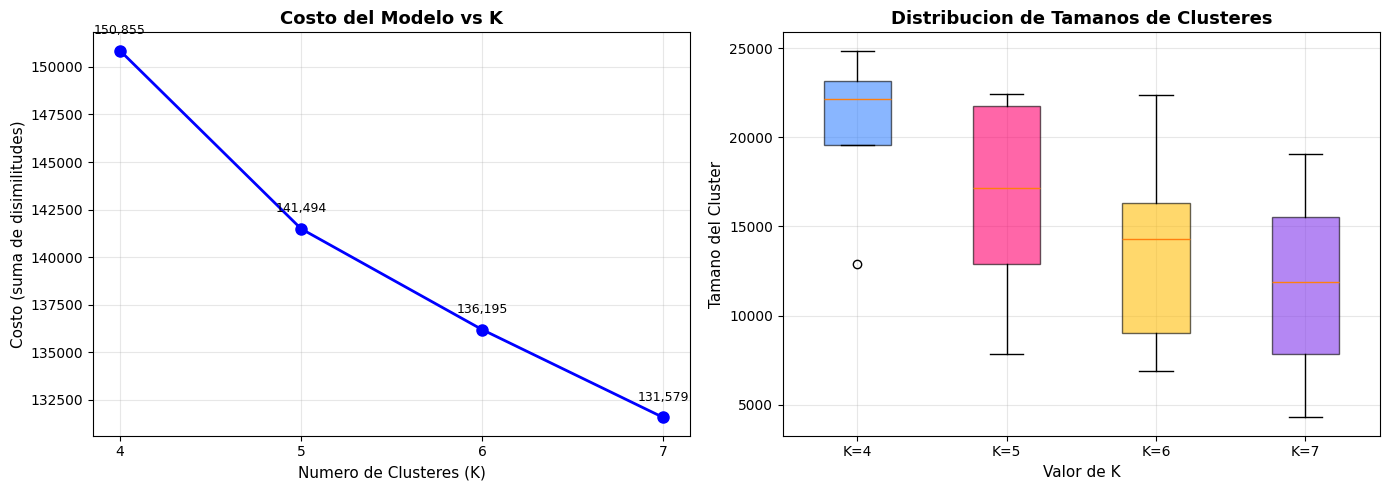

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Costo vs K
ks = df_resumen['K'].values
costos = df_resumen['Costo'].values

axes[0].plot(ks, costos, 'bo-', linewidth=2, markersize=8)
for i, (k_val, c_val) in enumerate(zip(ks, costos)):
    axes[0].annotate(f'{c_val:,.0f}', (k_val, c_val), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9)
axes[0].set_xlabel('Numero de Clusteres (K)', fontsize=11)
axes[0].set_ylabel('Costo (suma de disimilitudes)', fontsize=11)
axes[0].set_title('Costo del Modelo vs K', fontsize=13, fontweight='bold')
axes[0].set_xticks(ks)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Distribucion de tamanos por K
positions = []
data_sizes = []
labels_k = []
for _, row in df_resumen.iterrows():
    k_val = int(row['K'])
    sizes_list = eval(row['Distribucion'])
    data_sizes.append(sizes_list)
    labels_k.append(f'K={k_val}')

bp = axes[1].boxplot(data_sizes, labels=labels_k, patch_artist=True)
colores_box = ['#3a86ff', '#ff006e', '#ffbe0b', '#8338ec']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xlabel('Valor de K', fontsize=11)
axes[1].set_ylabel('Tamano del Cluster', fontsize=11)
axes[1].set_title('Distribucion de Tamanos de Clusteres', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Visualizacion: Distribucion de Sexo y Edad por Cluster (para cada K)

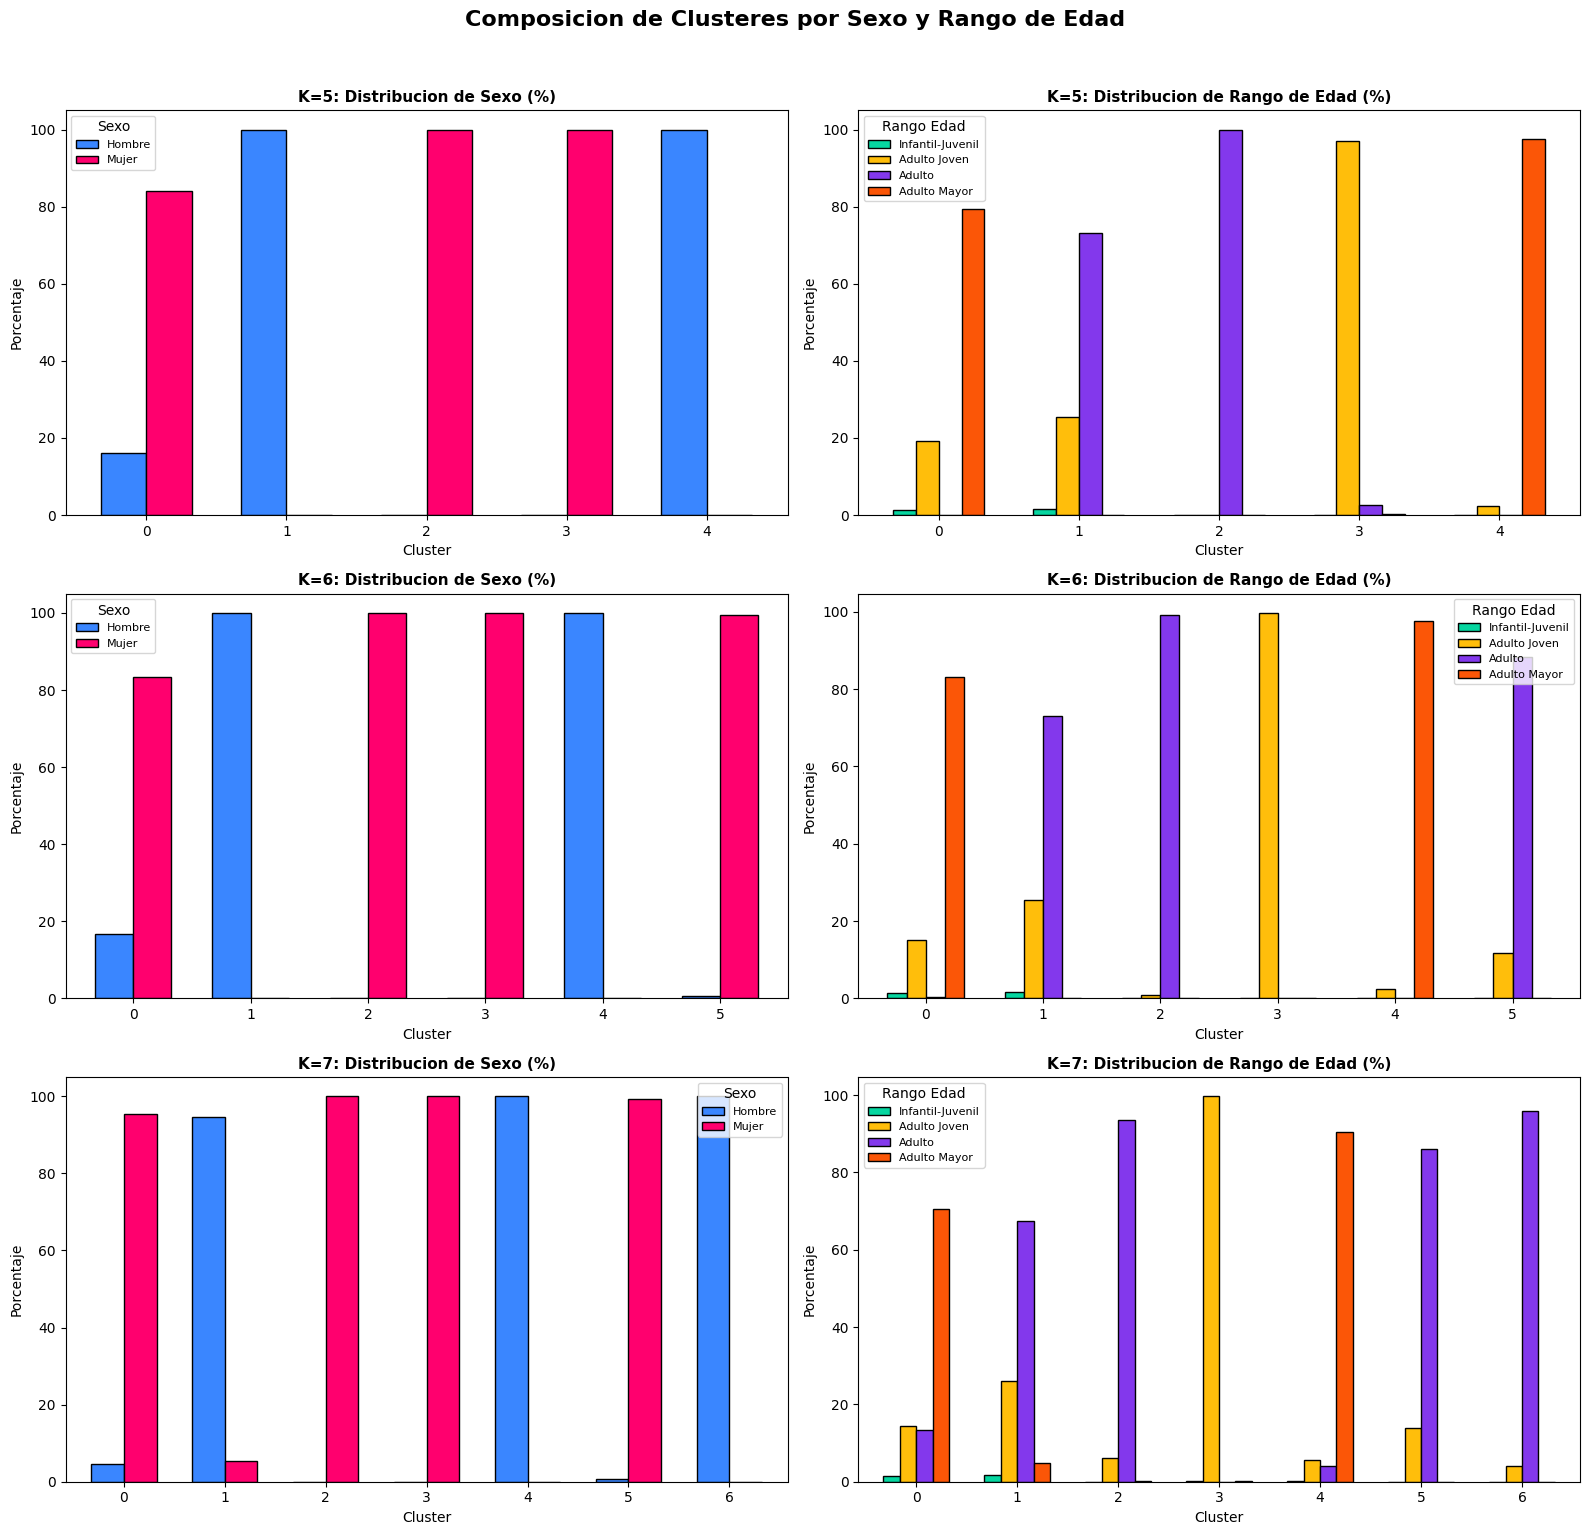

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Composicion de Clusteres por Sexo y Rango de Edad', fontsize=16, fontweight='bold', y=1.02)

datasets = [(5, df_subset_5), (6, df_subset_6), (7, df_subset_7)]

for i, (k_val, df_k) in enumerate(datasets):
    # Sexo
    sexo_cross = pd.crosstab(df_k['Cluster'], df_k['PTESXN'], normalize='index') * 100
    sexo_cross.plot(kind='bar', ax=axes[i, 0], edgecolor='black', width=0.65,
                    color=['#3a86ff', '#ff006e'])
    axes[i, 0].set_title(f'K={k_val}: Distribucion de Sexo (%)', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel('Cluster')
    axes[i, 0].set_ylabel('Porcentaje')
    axes[i, 0].tick_params(axis='x', rotation=0)
    axes[i, 0].legend(title='Sexo', fontsize=8)
    
    # Edad
    edad_cross = pd.crosstab(df_k['Cluster'], df_k['EDAD_RANGO'], normalize='index') * 100
    edad_cross.plot(kind='bar', ax=axes[i, 1], edgecolor='black', width=0.65,
                    color=['#06d6a0', '#ffbe0b', '#8338ec', '#fb5607'])
    axes[i, 1].set_title(f'K={k_val}: Distribucion de Rango de Edad (%)', fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel('Cluster')
    axes[i, 1].set_ylabel('Porcentaje')
    axes[i, 1].tick_params(axis='x', rotation=0)
    axes[i, 1].legend(title='Rango Edad', fontsize=8)

plt.tight_layout()
plt.show()

### 6.4 Comparativa de Perfiles: Tabla resumen de modas por K

In [14]:
# Tabla consolidada de perfiles para los 3 valores de K experimentales
col_topo = 'TOPOGRAF\u00cdA_N'
col_morf = 'MORFOLOG\u00cdA_N'

print('=' * 80)
print('PERFILES DE CLUSTERES POR VALOR DE K')
print('=' * 80)

for k_val, interp_df in [(5, interp_5), (6, interp_6), (7, interp_7)]:
    sep = '=' * 40
    print(f'\n{sep}')
    print(f'  K = {k_val}')
    print(sep)
    for idx, row in interp_df.iterrows():
        tamano = row['Tamano']
        sexo = row['PTESXN']
        topo = row[col_topo]
        morf = row[col_morf]
        edad = row['EDAD_RANGO']
        print(f'\n  Cluster {idx} (n={tamano:,}):')
        print(f'    Sexo:        {sexo}')
        print(f'    Topografia:  {topo}')
        print(f'    Morfologia:  {morf}')
        print(f'    Rango Edad:  {edad}')

SyntaxError: f-string expression part cannot include a backslash (1901509205.py, line 13)

### 6.5 Heatmap: Tamano de cada cluster por K

In [ ]:
# Construir matriz de tamanos (filas=K, columnas=cluster)
max_k = 7
tamanos_matrix = {}
for k_val, df_k in [(4, df_subset_4), (5, df_subset_5), (6, df_subset_6), (7, df_subset_7)]:
    sizes = df_k['Cluster'].value_counts().sort_index()
    for c in range(max_k):
        tamanos_matrix.setdefault(f'Cluster {c}', {})[f'K={k_val}'] = sizes.get(c, 0)

df_heatmap = pd.DataFrame(tamanos_matrix).T
df_heatmap = df_heatmap[['K=4', 'K=5', 'K=6', 'K=7']]

plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap, annot=True, fmt=',d', cmap='YlOrRd', linewidths=0.5)
plt.title('Tamano de Clusteres por Valor de K', fontsize=13, fontweight='bold')
plt.xlabel('Valor de K')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

### 6.6 Graficos de Dispersion: Clusteres en el espacio de variables codificadas

In [ ]:
# Graficos de dispersion: Topografia (codificada) vs Morfologia (codificada), coloreado por Cluster
# Se usa una muestra aleatoria para que el grafico sea legible (el dataset tiene 82k filas)

np.random.seed(42)
sample_idx = np.random.choice(len(df_encoded), size=min(5000, len(df_encoded)), replace=False)

paletas = ['tab10', 'Set1', 'Dark2', 'tab10']

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Dispersion de Clusteres: Topografia vs Morfologia (codificadas)',
             fontsize=16, fontweight='bold', y=1.02)

all_data = [
    (4, df_subset_4, clusters_4),
    (5, df_subset_5, clusters_5),
    (6, df_subset_6, clusters_6),
    (7, df_subset_7, clusters_7)
]

col_topo_enc = 'TOPOGRAF\u00cdA_N'
col_morf_enc = 'MORFOLOG\u00cdA_N'

for idx, (k_val, df_k, clust_labels) in enumerate(all_data):
    ax = axes[idx // 2, idx % 2]
    x_vals = df_encoded[col_topo_enc].values[sample_idx]
    y_vals = df_encoded[col_morf_enc].values[sample_idx]
    c_vals = clust_labels[sample_idx]

    scatter = ax.scatter(x_vals, y_vals, c=c_vals, cmap=paletas[idx],
                         alpha=0.5, s=8, edgecolors='none')
    legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=scatter.cmap(scatter.norm(c)), markersize=8,
                      label=f'Cluster {c}') for c in range(k_val)]
    ax.legend(handles=legend_handles, title='Cluster', fontsize=8, loc='upper right')
    ax.set_xlabel('Topografia (codificada)', fontsize=10)
    ax.set_ylabel('Morfologia (codificada)', fontsize=10)
    ax.set_title(f'K={k_val}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# Graficos de dispersion: Topografia (codificada) vs Edad Rango (codificada), coloreado por Cluster

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Dispersion de Clusteres: Topografia vs Rango de Edad (codificadas)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, (k_val, df_k, clust_labels) in enumerate(all_data):
    ax = axes[idx // 2, idx % 2]
    x_vals = df_encoded[col_topo_enc].values[sample_idx]
    y_vals = df_encoded['EDAD_RANGO'].values[sample_idx]
    c_vals = clust_labels[sample_idx]

    scatter = ax.scatter(x_vals, y_vals, c=c_vals, cmap=paletas[idx],
                         alpha=0.5, s=8, edgecolors='none')
    legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=scatter.cmap(scatter.norm(c)), markersize=8,
                      label=f'Cluster {c}') for c in range(k_val)]
    ax.legend(handles=legend_handles, title='Cluster', fontsize=8, loc='upper right')
    ax.set_xlabel('Topografia (codificada)', fontsize=10)
    ax.set_ylabel('Rango de Edad (codificado)', fontsize=10)
    ax.set_title(f'K={k_val}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# Graficos de dispersion: Sexo (codificado) vs Topografia (codificada), coloreado por Cluster

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Dispersion de Clusteres: Sexo vs Topografia (codificadas)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, (k_val, df_k, clust_labels) in enumerate(all_data):
    ax = axes[idx // 2, idx % 2]
    x_vals = df_encoded['PTESXN'].values[sample_idx]
    y_vals = df_encoded[col_topo_enc].values[sample_idx]
    c_vals = clust_labels[sample_idx]

    scatter = ax.scatter(x_vals, y_vals, c=c_vals, cmap=paletas[idx],
                         alpha=0.5, s=8, edgecolors='none')
    legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=scatter.cmap(scatter.norm(c)), markersize=8,
                      label=f'Cluster {c}') for c in range(k_val)]
    ax.legend(handles=legend_handles, title='Cluster', fontsize=8, loc='upper right')
    ax.set_xlabel('Sexo (codificado)', fontsize=10)
    ax.set_ylabel('Topografia (codificada)', fontsize=10)
    ax.set_title(f'K={k_val}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 7. Conclusiones

### 7.1 Tabla resumen de costos

| K | Costo | Reduccion vs K-1 | Tamano Min | Tamano Max |
|---|-------|-------------------|------------|------------|
| 4 | 150,855 | -- (referencia) | 12,920 | 24,851 |
| 5 | 141,494 | -9,361 (6.2%) | 7,866 | 22,396 |
| 6 | 136,195 | -5,299 (3.7%) | 6,909 | 22,367 |
| 7 | 131,579 | -4,616 (3.4%) | 4,298 | 19,068 |

### 7.2 Observaciones por valor de K

**K=4 (Referencia - Costo: 150,855):**
- 4 perfiles claros: Mama Adulto Mayor (24,851), Hombres Adultos (22,583), Mama Adultas (21,752), Cuello Uterino Joven (12,920).
- Todos los clusters con tamano >12,000 pacientes. Buena separacion genero-especifica.

**K=5 (Costo: 141,494):**
- El grupo de Hombres Adultos de K=4 se subdivide: aparece un **nuevo cluster de Hombres Adultos Mayores con Prostata (7,866)**, con el 97.6% de pacientes mayores de 65 anos.
- Es clinicamente relevante: separa cancer testicular (adultos jovenes) de cancer de prostata (adultos mayores).
- Clusters 2 y 3 se mantienen estables respecto a K=4.

**K=6 (Costo: 136,195):**
- Emerge un **cluster 5 de Mama con Carcinoma Ductal Infiltrante (6,909)**, mujeres adultas (88.3% entre 45-65 anos).
- Separa por morfologia: Adenocarcinoma generico vs Carcinoma Ductal Infiltrante especifico.
- Cluster 2 migra de Mama a **Cuello Uterino Adultas** (16,118), diferenciandose del cluster 3 (Cuello Uterino Adultas Jovenes con NIC III).
- Todos los clusters mantienen tamano razonable (>6,900).

**K=7 (Costo: 131,579):**
- Aparece un **cluster 6 de Hombres con cancer colorrectal (Recto/Colon, 4,298)**, con Adenocarcinoma, edad Adulta.
- Cluster 4 se amplia a Prostata Adulto Mayor (9,913) con separacion mas neta (90.4% >65 anos, 100% hombres).
- El cluster mas pequeno tiene 4,298 pacientes, todavia estadisticamente significativo.
- Mayor granularidad clinica sin fragmentacion excesiva.

### 7.3 Hallazgos clave de la experimentacion

1. **K=5 es la primera mejora significativa:** La separacion entre cancer testicular (jovenes) y cancer de prostata (mayores) tiene alto valor clinico.
2. **K=6 revela subtipos histologicos:** El Carcinoma Ductal Infiltrante de mama se distingue del Adenocarcinoma generico, y el cuello uterino se segmenta por edad.
3. **K=7 captura canceres digestivos:** Aparece un perfil de cancer colorrectal (recto + colon) en hombres adultos que antes estaba diluido.
4. **La reduccion de costo se desacelera:** De K=4 a K=5 se reduce un 6.2%, pero de K=6 a K=7 solo un 3.4%, indicando rendimientos decrecientes.
5. **Todos los K producen clusters con tamano razonable:** Incluso en K=7, el cluster mas pequeno tiene 4,298 pacientes (5.2% del total).

### 7.4 Recomendacion

Para un analisis equilibrado entre **interpretabilidad clinica** y **cohesion estadistica**, se recomienda **K=5 o K=6** como alternativas viables al K=4 original:
- **K=5** si se prioriza la simplicidad y la separacion genero-especifica.
- **K=6** si se desea mayor detalle histologico (subtipos de cancer de mama y cuello uterino).